# HW02-20234080327-赵果剑.ipynb
## 1. 作业要求

## 2. 多层感知机 (MLP) 基础
### 2.1 理论部分
1. **证明这仍然是一个线性模型，并求出等效的 W' 和 b'。**
   给定输入 $x$，隐层输出 $h = W_1x + b_1$，输出层输出 $o = W_2h + b_2$。
   将 $h$ 的表达式代入 $o$ 的表达式中：
   $o = W_2(W_1x + b_1) + b_2$
   $o = W_2W_1x + W_2b_1 + b_2$
   令 $W' = W_2W_1$ 且 $b' = W_2b_1 + b_2$。
   则 $o = W'x + b'$。
   这符合线性模型的定义，因此，即使经过两层线性变换，最终模型仍然是线性的。

2. **写出 Sigmoid(x) 和 tanh(x) 的定义，并求出它们的导数 Sigmoid'(x) 和 tanh'(x)。**
   *   **Sigmoid 函数**：
       定义：$\sigma(x) = \frac{1}{1 + e^{-x}}$ 
       导数：$\sigma'(x) = \sigma(x)(1 - \sigma(x))$ 

   *   **tanh 函数**：
       定义：$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ 
       导数：$\tanh'(x) = 1 - \tanh^2(x)$

### 2.2 实践部分
要求：不使用高级 API（如 nn.Linear），仅使用 Tensor 操作（如 torch.matmul）。使用 NumPy 或 PyTorch 在 Fashion-MNIST 数据集上实现一个 MLP。

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 数据准备
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. 初始化参数
num_inputs, num_outputs, num_hiddens = 784, 10, 256
W1 = torch.randn(num_inputs, num_hiddens) * 0.01
W1.requires_grad_(True)
b1 = torch.zeros(num_hiddens, requires_grad=True)
W2 = torch.randn(num_hiddens, num_outputs) * 0.01
W2.requires_grad_(True)
b2 = torch.zeros(num_outputs, requires_grad=True)

params = [W1, b1, W2, b2]

# 3. 激活函数
def relu(X):
    return torch.max(X, torch.zeros_like(X))

# 4. 模型
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2

# 5. 损失函数 (Cross Entropy from scratch)
def softmax(X):
    X_exp = torch.exp(X - torch.max(X, dim=1, keepdim=True)[0]) # stability
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y] + 1e-8)

# 6. 优化器
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            if param.grad is not None:
                param -= lr * param.grad / batch_size
                param.grad.zero_()

# 7. 训练
lr = 0.1
num_epochs = 5
for epoch in range(num_epochs):
    total_loss = 0
    for X, y in train_loader:
        y_hat = net(X)
        probs = softmax(y_hat)
        l = cross_entropy(probs, y).sum()
        l.backward()
        sgd(params, lr, 64)
        total_loss += l.item()
    print(f'epoch {epoch + 1}, loss {total_loss / len(train_dataset):.4f}')

# 8. 测试
def evaluate_accuracy(net, data_loader):
    acc_sum, n = 0.0, 0
    with torch.no_grad():
        for X, y in data_loader:
            acc_sum += (net(X).argmax(dim=1) == y).float().sum().item()
            n += y.shape[0]
    return acc_sum / n

print(f'Test accuracy: {evaluate_accuracy(net, test_loader):.4f}')

100.0%


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

epoch 1, loss 0.5670
epoch 2, loss 0.4018
epoch 3, loss 0.3615
epoch 4, loss 0.3345
epoch 5, loss 0.3135
Test accuracy: 0.8733


## 3. 模型选择与正则化
### 3.1 理论部分
1. **简述训练误差 (Training Error) 和泛化误差 (Generalization Error) 的区别。**
   *   **训练误差 (Training Error)**：模型在训练数据集上表现的误差。它衡量了模型对已知数据的拟合程度。训练误差越小，说明模型对训练数据拟合得越好。
   *   **泛化误差 (Generalization Error)**：模型在未见过的新数据上表现的误差。它衡量了模型推广到新数据的能力。泛化误差是衡量模型性能的更重要指标，因为它反映了模型在实际应用中的表现。
   **区别**：训练误差关注模型对训练数据的拟合能力，而泛化误差关注模型对未知数据的预测能力。一个好的模型应该在训练误差和泛化误差之间取得平衡，避免过拟合（训练误差低但泛化误差高）和欠拟合（训练误差和泛化误差都高）。

2. **解释 K 折交叉验证 (K-fold Cross-Validation) 的基本过程。**
   K 折交叉验证是一种常用的模型评估方法，旨在更可靠地评估模型的泛化能力，减少对特定训练集和测试集划分的依赖。其基本过程如下：
   1.  **数据划分**：将整个数据集随机分成 K 个大小近似相等的子集（折）。
   2.  **迭代训练与验证**：进行 K 次迭代。在每次迭代中：
       *   选择其中一个子集作为**验证集 (Validation Set)**。
       *   将其余 K-1 个子集合并作为**训练集 (Training Set)**。
       *   在训练集上训练模型。
       *   在验证集上评估模型的性能（例如，计算误差或准确率）。
   3.  **结果汇总**：K 次迭代完成后，将 K 个验证结果的平均值作为模型性能的最终评估指标。
   K 折交叉验证的优点在于充分利用了所有数据进行训练和验证，并且通过多次不同的划分，使得模型评估结果更加稳定和可靠。

### 3.2 实践部分
在 MLP 中加入 L2 正则化和 Dropout。

Training: No regularization...
Epoch 1, Loss: 0.5689
Epoch 2, Loss: 0.4030
Epoch 3, Loss: 0.3594
Epoch 4, Loss: 0.3347
Epoch 5, Loss: 0.3154
Training: L2 regularization...
Epoch 1, Loss: 0.5994
Epoch 2, Loss: 0.4721
Epoch 3, Loss: 0.4598
Epoch 4, Loss: 0.4562
Epoch 5, Loss: 0.4500
Training: Dropout...
Epoch 1, Loss: 0.6277
Epoch 2, Loss: 0.4682
Epoch 3, Loss: 0.4298
Epoch 4, Loss: 0.4069
Epoch 5, Loss: 0.3900


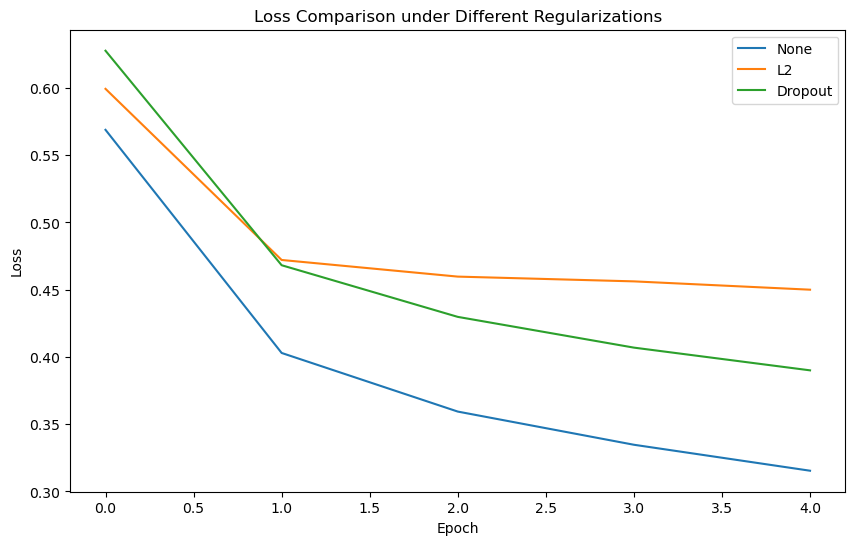

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 数据准备
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

num_inputs, num_outputs, num_hiddens = 784, 10, 256

def init_params():
    W1 = torch.randn(num_inputs, num_hiddens) * 0.01
    W1.requires_grad_(True)
    b1 = torch.zeros(num_hiddens, requires_grad=True)
    W2 = torch.randn(num_hiddens, num_outputs) * 0.01
    W2.requires_grad_(True)
    b2 = torch.zeros(num_outputs, requires_grad=True)
    return [W1, b1, W2, b2]

def relu(X):
    return torch.max(X, torch.zeros_like(X))

def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

def net(X, params, dropout=0, is_training=True):
    W1, b1, W2, b2 = params
    X = X.reshape((-1, num_inputs))
    H = relu(torch.matmul(X, W1) + b1)
    H = dropout_layer(H, dropout, is_training)
    return torch.matmul(H, W2) + b2

def sgd_weighted(params, lr, batch_size, lambd=0):
    with torch.no_grad():
        for param in params:
            if param.grad is not None:
                param -= lr * (param.grad / batch_size + lambd * param)
                param.grad.zero_()

def train(lambd=0, dropout=0, num_epochs=5):
    params = init_params()
    loss_list = []
    for epoch in range(num_epochs):
        total_loss = 0
        for X, y in train_loader:
            y_hat = net(X, params, dropout, is_training=True)
            l = torch.nn.CrossEntropyLoss()(y_hat, y)
            l.backward()
            sgd_weighted(params, 0.1, 1, lambd)
            total_loss += l.item()
        avg_loss = total_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    return loss_list

print("Training: No regularization...")
loss_none = train(lambd=0, dropout=0)
print("Training: L2 regularization...")
loss_l2 = train(lambd=0.01, dropout=0)
print("Training: Dropout...")
loss_dropout = train(lambd=0, dropout=0.5)

plt.figure(figsize=(10, 6))
plt.plot(loss_none, label='None')
plt.plot(loss_l2, label='L2')
plt.plot(loss_dropout, label='Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison under Different Regularizations')
plt.legend()
plt.show()

## 4. 梯度消失与梯度爆炸
### 4.1 理论部分
1. **考虑深度网络中梯度的乘积项，解释为什么会发生梯度消失或梯度爆炸。**
   在深度神经网络中，反向传播算法通过链式法则计算梯度。梯度的计算涉及到多层之间权重的连续乘积。
   *   **梯度消失 (Vanishing Gradients)**：当网络中的激活函数（如 Sigmoid 或 Tanh）的导数在大部分区域都非常小（例如，Sigmoid 函数在输入值较大或较小时导数接近于 0），或者权重矩阵的范数小于 1 时，多个这样的导数或权重相乘会导致梯度值指数级减小。这意味着靠近输入层的层的权重更新会非常缓慢，甚至停滞，导致这些层无法有效学习。
   *   **梯度爆炸 (Exploding Gradients)**：当网络中的权重矩阵的范数大于 1 时，多个这样的权重相乘会导致梯度值指数级增大。这会导致模型参数的剧烈变化，使得训练过程不稳定，甚至出现 NaN 值，从而无法收敛。

2. **为什么 ReLU 激活函数能在一定程度上缓解梯度消失问题？**
   ReLU (Rectified Linear Unit) 激活函数的定义是 $f(x) = \max(0, x)$。它的导数在 $x > 0$ 时为 1，在 $x < 0$ 时为 0。
   *   **导数恒定**：对于正输入，ReLU 的导数是常数 1。这意味着在反向传播过程中，只要神经元的输入是正的，梯度就不会因为激活函数而衰减，从而避免了梯度消失。
   *   **稀疏激活**：对于负输入，ReLU 的导数是 0，这会导致一些神经元“死亡”（即不再激活），从而引入稀疏性，这在某些情况下可以帮助模型学习到更鲁棒的特征。
   虽然 ReLU 可以缓解梯度消失，但它也可能导致“死亡 ReLU”问题，即一旦神经元输入变为负值，它将永远不会被激活，梯度也永远为 0。LeakyReLU 等变体被提出以解决这个问题。

### 4.2 实践部分
梯度消失与梯度爆炸的实验。

In [3]:
import torch
import torch.nn as nn

def check_gradient_norm(model, input_data):
    model.zero_grad()
    output = model(input_data)
    loss = output.mean()
    loss.backward()
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5
    return total_norm

# 1. 20层深度网络
def get_model(activation_fn):
    layers = []
    for i in range(20):
        layers.append(nn.Linear(256, 256))
        layers.append(activation_fn())
    return nn.Sequential(*layers)

input_data = torch.randn(1, 256)

# 2. Normal init, Sigmoid
model_sig = get_model(nn.Sigmoid)
for m in model_sig.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)
        nn.init.zeros_(m.bias)
print(f"Sigmoid Gradient Norm: {check_gradient_norm(model_sig, input_data)}")

# 3. ReLU, std=10
model_relu_std10 = get_model(nn.ReLU)
for m in model_relu_std10.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
        nn.init.zeros_(m.bias)
print(f"ReLU (std=10) Gradient Norm: {check_gradient_norm(model_relu_std10, input_data)}")

# 4. Xavier init, ReLU vs LeakyReLU
model_xavier_relu = get_model(nn.ReLU)
for m in model_xavier_relu.modules():
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)
print(f"Xavier ReLU Gradient Norm: {check_gradient_norm(model_xavier_relu, input_data)}")

model_xavier_leaky = get_model(nn.LeakyReLU)
for m in model_xavier_leaky.modules():
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)
print(f"Xavier LeakyReLU Gradient Norm: {check_gradient_norm(model_xavier_leaky, input_data)}")

Sigmoid Gradient Norm: 6.281996673209057
ReLU (std=10) Gradient Norm: nan
Xavier ReLU Gradient Norm: 0.0849895543879247
Xavier LeakyReLU Gradient Norm: 0.07545372724961207


## 5. 分布偏移
### 5.1 理论部分
1. **定义协变量偏移 (Covariate Shift)：p(x) != q(x) 但 p(y|x) = q(y|x)。**
   **协变量偏移**指的是训练集和测试集（或目标域）的输入特征 $x$ 的分布不同，即 $p(x) \neq q(x)$，但给定输入特征 $x$ 的条件下，输出 $y$ 的条件概率分布是相同的，即 $p(y|x) = q(y|x)$。这意味着输入特征的统计特性发生了变化，但特征与标签之间的基本关系保持不变。

2. **定义标签偏移 (Label Shift)：p(y) != q(y) 但 p(x|y) = q(x|y)。**
   **标签偏移**指的是训练集和测试集（或目标域）的标签 $y$ 的分布不同，即 $p(y) \neq q(y)$，但给定标签 $y$ 的条件下，输入特征 $x$ 的条件概率分布是相同的，即 $p(x|y) = q(x|y)$。这意味着标签的统计特性发生了变化，但标签与特征之间的基本关系保持不变。

### 5.2 实践部分
分布偏移修正实验。

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 生成训练集 P
torch.manual_seed(42)
x_train = torch.normal(-1, 1, (1000, 1))
y_train = 2 * x_train + torch.randn(1000, 1) * 0.1

# 2. 生成测试集 Q
x_test = torch.normal(2, 1, (500, 1))
y_test = 2 * x_test + torch.randn(500, 1) * 0.1

# 3. 在 P 上训练线性回归模型
model = nn.Linear(1, 1)
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

# 在 Q 上测试
with torch.no_grad():
    y_test_pred = model(x_test)
    mse_q = criterion(y_test_pred, y_test)
print(f"MSE on Q (without correction): {mse_q.item():.4f}")

# 4. 修正协变量偏移
def normal_pdf(x, mean, std):
    return torch.exp(-0.5 * ((x - mean) / std)**2) / (std * (2 * 3.1415926)**0.5)

p_train_x = normal_pdf(x_train, -1, 1)
p_test_x = normal_pdf(x_train, 2, 1)
weights = p_test_x / p_train_x

# 使用加权损失函数进行训练
model_corr = nn.Linear(1, 1)
optimizer_corr = optim.SGD(model_corr.parameters(), lr=0.01)

for epoch in range(100):
    optimizer_corr.zero_grad()
    y_pred = model_corr(x_train)
    loss = (weights * (y_pred - y_train)**2).mean()
    loss.backward()
    optimizer_corr.step()

# 在 Q 上测试修正后的模型
with torch.no_grad():
    y_test_pred_corr = model_corr(x_test)
    mse_q_corr = criterion(y_test_pred_corr, y_test)
print(f"MSE on Q (with correction): {mse_q_corr.item():.4f}")

MSE on Q (without correction): 1.7983
MSE on Q (with correction): 0.0155
